# E3 — PoinTr v6: datos completos + más épocas

Versión definitiva del experimento. Añade ShapeNet a la mezcla y extiende a 500 épocas.

| Dataset | Pares | Estado |
|---------|-------|--------|
| Fantastic Breaks v2 | ~61 | ✅ Rocío-cleaned |
| Objaverse v2 | ~397 | ✅ Rocío-cleaned |
| ShapeNet roturas | ~2104 | ✅ limpio |

**Hipótesis:** ShapeNet (2104 pares limpios) + más épocas mejoran la generalización de v5_obj (CD=0.0306).

**Experimentos sugeridos:**
1. `FB=F OBJ=T SN=T` → v6_obj_sn — Objaverse + ShapeNet (recomendado 1º)
2. `FB=T OBJ=T SN=T` → v6_all — todo junto (recomendado 2º)
3. `FB=F OBJ=T SN=F` → v6_obj_long — igual que v5_obj pero 500 épocas

**Referencia:** PoinTr v5_obj (Ob v2, 300ep): **CD=0.0306, F=0.2701** ← beat this

In [1]:
# ── CELDA 1: Montar Drive ──────────────────────────────────────
from google.colab import drive
import os
if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
    print('Drive ya montado.')
else:
    drive.mount('/content/drive')
    print('Drive montado.')

Mounted at /content/drive
Drive montado.


In [2]:
# ── CELDA 2: Clonar repos + instalar dependencias ──────────────
import os, subprocess
from getpass import getpass

if not os.path.exists('/content/PoinTr'):
    subprocess.run(['git','clone','https://github.com/yuxumin/PoinTr',
                    '/content/PoinTr','--depth=1','-q'], capture_output=True)
    print('PoinTr clonado.')
else:
    print('[OK] /content/PoinTr ya existe.')

REPO_DIR = '/content/TFM'
if not os.path.exists(REPO_DIR):
    token = getpass('Token GitHub (ghp_...): ')
    subprocess.run(['git','clone',f'https://{token}@github.com/herredoble/TFM-reconstruccion-3D',
                    REPO_DIR,'-q'], capture_output=True)
    del token; print('Repo TFM clonado.')
else:
    subprocess.run(['git','-C',REPO_DIR,'pull','-q'], capture_output=True)
    print('[OK] /content/TFM actualizado.')

os.chdir(REPO_DIR)
subprocess.run(['git','checkout','raquel/e3','-q'], capture_output=True)
subprocess.run(['pip','install','timm','easydict','pyyaml','--quiet'])
print('[OK] timm easydict pyyaml')

for ext_name, ext_path in [
    ('pointnet2_ops', '/content/PoinTr/extensions/pointnet2_ops_lib'),
    ('chamfer_dist',  '/content/PoinTr/extensions/chamfer_dist'),
]:
    r = subprocess.run(['pip','install','-e',ext_path,'--quiet'], capture_output=True, text=True)
    print(f'[{"OK" if r.returncode==0 else "WARN fallback"}] {ext_name}')

PoinTr clonado.
Token GitHub (ghp_...): ··········
Repo TFM clonado.
[OK] timm easydict pyyaml
[WARN fallback] pointnet2_ops
[OK] chamfer_dist


In [3]:
# ══════════════════════════════════════════════════════════════
# CELDA 3 — CONFIGURACION  (solo cambia esto entre experimentos)
# ══════════════════════════════════════════════════════════════

USAR_FB_V2      = False  # Fantastic Breaks v2  — 61 pares reales
USAR_OBJAVERSE  = True   # Objaverse v2         — 397 pares, Rocío-cleaned
USAR_SHAPENET   = True   # ShapeNet roturas     — 2104 pares limpios

EPOCHS = 500             # v5 usó 300 — aquí extendemos
LR     = 1e-4
BATCH  = 32

# ── VERSION se genera sola (prefijo v6) ───────────────────────
_partes = []
if USAR_FB_V2:      _partes.append('fb')
if USAR_OBJAVERSE:  _partes.append('obj')
if USAR_SHAPENET:   _partes.append('sn')
if not _partes:
    raise ValueError('Activa al menos un dataset')
VERSION = 'v6_' + '_'.join(_partes)

print(f'VERSION : {VERSION}')
print(f'Datasets: {_partes}')
print(f'Epochs  : {EPOCHS}  LR={LR}  Batch={BATCH}')
print(f'Referencia a batir: PoinTr v5_obj CD=0.0306, F=0.2701')

VERSION : v6_obj_sn
Datasets: ['obj', 'sn']
Epochs  : 500  LR=0.0001  Batch=32
Referencia a batir: PoinTr v5_obj CD=0.0306, F=0.2701


In [4]:
# ── CELDA 4: Rutas y verificación ──────────────────────────────
from pathlib import Path

DRIVE        = '/content/drive/MyDrive'
BASE_E3      = f'{DRIVE}/Datos_E2_E3/E3/Raquel'
BASE_GENERAL = f'{DRIVE}/Datos_E2_E3/General'

FUENTES_TODAS = {
    'fb':  (f'{BASE_GENERAL}/Fantastik_Break_Procesado_v2',
            'Datos/fantastic_breaks/procesado_v2'),
    'obj': (f'{BASE_GENERAL}/roturas_Objaverse_v2',
            'Datos/objaverse/roturas_v2'),
    'sn':  (f'{BASE_GENERAL}/shapenet_roturas',
            'Datos/shapenet/roturas'),
}

FUENTES_ACTIVAS = {k: v for k, v in FUENTES_TODAS.items() if k in _partes}

RUTA_SALIDA_MODELO     = f'{BASE_E3}/modelos/{VERSION}'
RUTA_SALIDA_RESULTADOS = f'{BASE_E3}/resultados/{VERSION}'

print(f'Rutas activas para {VERSION}:')
ok_todos = True
for clave, (drive_path, local_path) in FUENTES_ACTIVAS.items():
    existe = Path(drive_path).exists()
    n = 0
    if existe:
        n = len(list(Path(drive_path).glob('*_completo.npy')))
    estado = f'OK — {n} pares' if existe else 'FALTA — revisa el nombre'
    print(f'  [{"OK" if existe else "!!"}] {clave}: {drive_path}')
    print(f'        {estado}')
    if not existe: ok_todos = False

if not ok_todos:
    print('\n⚠️  Algunas carpetas no existen. Comprueba los nombres en FUENTES_TODAS.')
else:
    print('\n[OK] Todas las rutas verificadas.')

Rutas activas para v6_obj_sn:
  [OK] obj: /content/drive/MyDrive/Datos_E2_E3/General/roturas_Objaverse_v2
        OK — 397 pares
  [OK] sn: /content/drive/MyDrive/Datos_E2_E3/General/shapenet_roturas
        OK — 2104 pares

[OK] Todas las rutas verificadas.


In [5]:
# ── CELDA 5: Copiar datos desde Drive ──────────────────────────
import subprocess
from pathlib import Path

for clave, (drive_path, local_path) in FUENTES_ACTIVAS.items():
    dst = Path(local_path)
    if dst.exists() and any(dst.glob('*.npy')):
        n = len(list(dst.glob('*.npy')))
        print(f'[OK] {clave} ya existe localmente ({n} .npy)')
        continue
    if not Path(drive_path).exists():
        print(f'[SKIP] {clave}: ruta Drive no encontrada — {drive_path}')
        continue
    dst.mkdir(parents=True, exist_ok=True)
    print(f'Copiando {clave} (puede tardar unos minutos con ShapeNet)...')
    r = subprocess.run(['rsync','-a','--no-links',f'{drive_path}/',str(dst)],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  [ERROR rsync] {r.stderr[:200]}')
    else:
        n = len(list(dst.glob('*.npy')))
        print(f'  listo — {n} archivos .npy')

Copiando obj (puede tardar unos minutos con ShapeNet)...
  listo — 794 archivos .npy
Copiando sn (puede tardar unos minutos con ShapeNet)...
  listo — 4208 archivos .npy


In [6]:
# ── CELDA 6: Verificar GPU ─────────────────────────────────────
import torch
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  Sin GPU — cambia a T4/A100')

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [7]:
# ── CELDA 7: ENTRENAR ──────────────────────────────────────────
import sys, os, math, time, types, glob as _glob, shutil, random, json
from pathlib import Path
from datetime import date

sys.path.insert(0, '/content/PoinTr')
sys.path.insert(0, '/content/TFM')
os.chdir('/content/TFM')

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from easydict import EasyDict

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_STR = str(device)
print(f'Dispositivo: {device}')
if device.type == 'cpu':
    raise SystemExit('Sin GPU — cambia a T4/A100')

# ── Reset cache PoinTr ───────────────────────────────────────
_pfx = ('models','utils.registry','utils.config','utils.logger','utils.misc','extensions')
_del = [k for k,v in sys.modules.items()
        if any(k==p or k.startswith(p+'.') for p in _pfx)
        or (hasattr(v,'__file__') and v.__file__ and '/content/PoinTr' in str(v.__file__))]
for k in _del: del sys.modules[k]
print(f'[reset] {len(_del)} modulos PoinTr')

# ── Patch .cuda() ────────────────────────────────────────────
_np = 0
for fp in _glob.glob('/content/PoinTr/models/*.py')+_glob.glob('/content/PoinTr/models/**/*.py'):
    try:
        src = open(fp, encoding='utf-8').read()
        new = src.replace('.cuda()', f'.to("{DEVICE_STR}")')
        if new != src: open(fp,'w',encoding='utf-8').write(new); _np+=1
    except: pass
print(f'[patch] {_np} archivos')

# ── Mocks CUDA ───────────────────────────────────────────────
def _force(name, attrs):
    m = types.ModuleType(name)
    for k,v in attrs.items(): setattr(m,k,v)
    sys.modules[name] = m

def _inject(name, attrs):
    if name not in sys.modules: _force(name, attrs)

def _chamfer_raw(a,b):
    d=torch.cdist(a,b,p=2); return d.min(2).values, d.min(1).values

class _ChamferL1(nn.Module):
    def forward(self,a,b):
        d1,d2=_chamfer_raw(a.contiguous(),b.contiguous()); return (d1.mean()+d2.mean())/2
class _ChamferL2(nn.Module):
    def forward(self,a,b):
        d1,d2=_chamfer_raw(a.contiguous(),b.contiguous()); return ((d1**2).mean()+(d2**2).mean())/2
class _ChamferL1_PM(nn.Module):
    def forward(self,a,b): return torch.cdist(a.contiguous(),b.contiguous(),p=2).min(2).values.mean()

_ch={'ChamferDistanceL1':_ChamferL1,'ChamferDistanceL2':_ChamferL2,
     'ChamferDistanceL1_PM':_ChamferL1_PM,'chamfer_3DDist':_chamfer_raw}
for n in ['chamfer','chamfer_dist','extensions.chamfer_dist','chamfer3D','chamfer3D.dist_chamfer_3D']:
    _force(n,_ch)
print('[OK] Mock chamfer')

if 'pointnet2_ops' not in sys.modules:
    def _fps(xyz,np_):
        B,N,_=xyz.shape; dev=xyz.device
        idx=torch.zeros(B,np_,dtype=torch.int32,device=dev)
        dist=torch.full((B,N),1e10,device=dev)
        far=torch.randint(0,N,(B,),dtype=torch.long,device=dev)
        bi=torch.arange(B,dtype=torch.long,device=dev)
        for i in range(np_):
            idx[:,i]=far.int(); c=xyz[bi,far].unsqueeze(1)
            dist=torch.min(dist,((xyz-c)**2).sum(-1)); far=dist.max(-1)[1]
        return idx
    def _go(f,idx): B,C,N=f.shape; M=idx.shape[1]; return f.gather(2,idx.long().unsqueeze(1).expand(B,C,M)).contiguous()
    def _bq(r,ns,xyz,nxyz):
        d=torch.cdist(nxyz.float(),xyz.float()); s=d.argsort(-1)[:,:,:ns]
        return torch.where(d.gather(2,s)>r,s[:,:,:1].expand_as(s),s).int()
    def _grp(f,idx):
        B,C,N=f.shape; S,K=idx.shape[1],idx.shape[2]
        return f.gather(2,idx.long().view(B,1,S*K).expand(B,C,S*K)).view(B,C,S,K).contiguous()
    def _3nn(u,k): d=torch.cdist(u.float(),k.float()); d2,i=d.topk(3,-1,largest=False); return d2.float(),i.int()
    def _3i(f,idx,w):
        B,C,M=f.shape; N=idx.shape[1]
        return (f.gather(2,idx.long().view(B,1,N*3).expand(B,C,N*3)).view(B,C,N,3)*w.unsqueeze(1)).sum(-1).contiguous()
    _pu=types.ModuleType('pointnet2_ops.pointnet2_utils')
    for k,v in {'furthest_point_sample':_fps,'gather_operation':_go,'ball_query':_bq,
                'grouping_operation':_grp,'three_nn':_3nn,'three_interpolate':_3i}.items(): setattr(_pu,k,v)
    _pm=types.ModuleType('pointnet2_ops'); _pm.pointnet2_utils=_pu
    sys.modules['pointnet2_ops']=_pm; sys.modules['pointnet2_ops.pointnet2_utils']=_pu
    print('[OK] Mock pointnet2_ops')

class _KNN(nn.Module):
    def __init__(self,k,transpose_mode=False): super().__init__(); self.k=k; self.tm=transpose_mode
    def forward(self,ref,query):
        if self.tm: d=torch.cdist(query.float(),ref.float()); dk,ik=d.topk(self.k,-1,largest=False); return dk,ik
        r=ref.transpose(1,2).contiguous(); q=query.transpose(1,2).contiguous()
        d=torch.cdist(q.float(),r.float()); dk,ik=d.topk(self.k,-1,largest=False)
        return dk.transpose(1,2),ik.transpose(1,2)
_force('knn_cuda',{'KNN':_KNN})

def _dc(n): return type(n,(nn.Module,),{'__init__':lambda s,*a,**k:super(type(s),s).__init__(),'forward':lambda s,x,*a,**k:x})
class _Emd(nn.Module):
    def forward(self,a,b): return torch.zeros(a.shape[0],device=a.device),torch.zeros(a.shape[0],dtype=torch.int32,device=a.device)
for base,attrs in [('gridding',{'Gridding':_dc('G'),'GriddingReverse':_dc('GR')}),
                   ('gridding_loss',{'GriddingLoss':_dc('GL')}),
                   ('cubic_feature_sampling',{'CubicFeatureSampling':_dc('CFS')}),
                   ('emd',{'emd_module':_Emd,'EarthMoverDistance':_Emd})]:
    for pfx in ['','extensions.']: _inject(pfx+base,attrs)
print('[OK] Mocks restantes')

from extensions.chamfer_dist import ChamferDistanceL1 as _CDL1
_cd_fn=_CDL1()
def chamfer_distance(p,g): return _cd_fn(p.contiguous(),g.contiguous())
def subsample_gt(gt,n): return gt[:,torch.randperm(gt.size(1),device=gt.device)[:n],:]

# ── Config y modelo ──────────────────────────────────────────
import yaml
cfg_path='/content/PoinTr/cfgs/PCN_models/PoinTr.yaml'
if not os.path.exists(cfg_path):
    cands=_glob.glob('/content/PoinTr/cfgs/**/PoinTr.yaml',recursive=True)
    cfg_path=cands[0] if cands else None
if cfg_path and os.path.exists(cfg_path):
    with open(cfg_path) as f: raw=yaml.safe_load(f)
    model_cfg=EasyDict(raw.get('model',raw))
else:
    model_cfg=EasyDict({'NAME':'PoinTr'})
model_cfg.num_pred=2048; model_cfg.num_query=128

try:
    from models.build import build_model_from_cfg; model=build_model_from_cfg(model_cfg)
except Exception as e1:
    from models.PoinTr import PoinTr; model=PoinTr(model_cfg)
model=model.to(device)
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

# ── Dataset: combinar fuentes activas ────────────────────────
from E3.dataset import construir_pares, ShapeCompletionDataset
import E3.dataset as _ds
_ds.CENTRAR_EN_ROTO=False

carpetas_locales=[v[1] for v in FUENTES_ACTIVAS.values() if Path(v[1]).exists()]
if not carpetas_locales:
    raise RuntimeError('No hay datos locales — ejecuta Celda 5 primero')

_todos=construir_pares(carpetas_locales)
print(f'Total pares: {len(_todos)} (de {carpetas_locales})')

_rng=random.Random(42); _rng.shuffle(_todos); _n=len(_todos)
_nt=int(0.8*_n); _nv=int(0.1*_n)
_tr=_todos[:_nt]; _va=_todos[_nt:_nt+_nv]; _te=_todos[_nt+_nv:]
print(f'  Train:{len(_tr)} Val:{len(_va)} Test:{len(_te)}')

train_loader=DataLoader(ShapeCompletionDataset(_tr,augmentar=True), batch_size=BATCH,shuffle=True,pin_memory=True)
val_loader  =DataLoader(ShapeCompletionDataset(_va,augmentar=False),batch_size=BATCH,shuffle=False,pin_memory=True)
test_loader =DataLoader(ShapeCompletionDataset(_te,augmentar=False),batch_size=BATCH,shuffle=False,pin_memory=True)
print(f'Batches: train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}')

# ── Hyperparams y resume ─────────────────────────────────────
CKPT_DIR=Path(f'E3/checkpoints_pointr_{VERSION}'); CKPT_DIR.mkdir(parents=True,exist_ok=True)
optimizer=AdamW(model.parameters(),lr=LR,weight_decay=5e-4)
scheduler=CosineAnnealingLR(optimizer,T_max=EPOCHS,eta_min=1e-6)
mejor_val=math.inf; train_losses=[]; val_losses=[]; START_EPOCH=1

def _find_latest_ckpt():
    dc=sorted(Path(RUTA_SALIDA_MODELO).glob('epoch_*.pt')) if Path(RUTA_SALIDA_MODELO).exists() else []
    lc=sorted(CKPT_DIR.glob('epoch_*.pt'))
    all_c=dc+lc
    if not all_c: return None
    def _ep(p):
        try: return int(p.stem.split('_')[1])
        except: return 0
    return max(all_c,key=_ep)

latest=_find_latest_ckpt()
if latest:
    print(f'Reanudando desde: {latest}')
    ck=torch.load(latest,map_location=device,weights_only=False)
    model.load_state_dict(ck['model_state_dict'])
    optimizer.load_state_dict(ck['optimizer_state_dict'])
    train_losses=ck.get('train_losses',[]); val_losses=ck.get('val_losses',[])
    START_EPOCH=ck['epoch']+1; mejor_val=min(val_losses) if val_losses else math.inf
    for _ in range(START_EPOCH-1): scheduler.step()
    print(f'  Desde {START_EPOCH}/{EPOCHS} | mejor val={mejor_val:.6f}')
else:
    print('Entrenamiento desde epoca 1')

if START_EPOCH>EPOCHS:
    print(f'Entrenamiento ya completo ({EPOCHS} epocas).')
    db=Path(RUTA_SALIDA_MODELO)/'best.pt'; lb=CKPT_DIR/'best.pt'
    if not lb.exists() and db.exists(): shutil.copy2(db,lb); print(f'[OK] best.pt copiado')
    print('Pasa a Celda 9.'); raise SystemExit('Completado.')

def guardar_ckpt(nombre,epoch):
    data={'epoch':epoch,'model_state_dict':model.state_dict(),
          'optimizer_state_dict':optimizer.state_dict(),
          'train_losses':train_losses,'val_losses':val_losses,'model_cfg':dict(model_cfg)}
    lp=CKPT_DIR/nombre; torch.save(data,lp)
    try:
        Path(RUTA_SALIDA_MODELO).mkdir(parents=True,exist_ok=True)
        shutil.copy2(lp,Path(RUTA_SALIDA_MODELO)/nombre)
    except Exception as e: print(f'  [WARN Drive] {e}')

print(f'\n{"Epoca":>7}  {"Train":>10}  {"Val":>10}  {"LR":>9}  {"Tiempo":>7}')
print('-'*52)

for epoch in range(START_EPOCH,EPOCHS+1):
    t0=time.time(); model.train(); tl=0.0
    for roto,completo in train_loader:
        roto,completo=roto.to(device),completo.to(device)
        optimizer.zero_grad()
        out=model(roto); c=out[0] if isinstance(out,(list,tuple)) else out
        f=out[-1] if isinstance(out,(list,tuple)) else out
        loss=chamfer_distance(f,completo)+0.5*chamfer_distance(c,subsample_gt(completo,c.size(1)))
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),10.0)
        optimizer.step(); tl+=loss.item()
    model.eval(); vl=0.0
    with torch.no_grad():
        for roto,completo in val_loader:
            roto,completo=roto.to(device),completo.to(device)
            out=model(roto); c=out[0] if isinstance(out,(list,tuple)) else out
            f=out[-1] if isinstance(out,(list,tuple)) else out
            vl+=(chamfer_distance(f,completo)+0.5*chamfer_distance(c,subsample_gt(completo,c.size(1)))).item()
    lt=tl/len(train_loader); lv=vl/len(val_loader); elapsed=time.time()-t0
    train_losses.append(lt); val_losses.append(lv); scheduler.step(); lr_now=scheduler.get_last_lr()[0]
    print(f'{epoch:>4}/{EPOCHS}  {lt:>10.6f}  {lv:>10.6f}  {lr_now:>9.2e}  {elapsed:>6.1f}s')
    if epoch%10==0: guardar_ckpt(f'epoch_{epoch:03d}.pt',epoch)
    if lv<mejor_val: mejor_val=lv; guardar_ckpt('best.pt',epoch); print(f'  -> best (val={mejor_val:.6f})')

print(f'\nFin. Mejor val: {mejor_val:.6f} | ckpts en {CKPT_DIR}')

Dispositivo: cuda
[reset] 0 modulos PoinTr
[patch] 5 archivos
[OK] Mock chamfer
[OK] Mock pointnet2_ops
[OK] Mocks restantes


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2026-08-27 19:23:18,741 - MODEL - INFO -  Transformer with knn_layer 1


Params: 42,202,854
Total pares: 2501 (de ['Datos/objaverse/roturas_v2', 'Datos/shapenet/roturas'])
  Train:2000 Val:250 Test:251
Batches: train=63 val=8 test=8
Entrenamiento desde epoca 1

  Epoca       Train         Val         LR   Tiempo
----------------------------------------------------
   1/500    0.147570    0.132383   1.00e-04    18.3s
  -> best (val=0.132383)
   2/500    0.122197    0.112497   1.00e-04    16.5s
  -> best (val=0.112497)
   3/500    0.114216    0.108228   1.00e-04    16.5s
  -> best (val=0.108228)
   4/500    0.109529    0.101862   1.00e-04    16.3s
  -> best (val=0.101862)
   5/500    0.106213    0.099282   1.00e-04    16.3s
  -> best (val=0.099282)
   6/500    0.103729    0.097379   1.00e-04    17.1s
  -> best (val=0.097379)
   7/500    0.102628    0.094466   1.00e-04    16.3s
  -> best (val=0.094466)
   8/500    0.100872    0.093063   9.99e-05    16.2s
  -> best (val=0.093063)
   9/500    0.099854    0.093802   9.99e-05    16.2s
  10/500    0.099091    0.090

## Evaluación y visualización

**Si la sesión de Colab se interrumpe**, ejecuta solo las celdas 1–3 para restaurar `VERSION`, `_partes`, `FUENTES_ACTIVAS` y `RUTA_SALIDA_*`, luego salta a la Celda 9.

**Celda 8** — Curvas de validación durante el entrenamiento (útil si ejecutas desde Colab sin haber entrenado ahora)  
**Celda 9** — Evaluación formal en test set → guarda `metricas.json`  
**Celda 10** — Curvas de aprendizaje (train vs val loss)  
**Celda 11** — Visualización 3D overlay (rota con el ratón)  
**Celda 12** — Puntos correctos vs erróneos (error coloring)

Checkpoint: epoch_500.pt  |  época 500/500
Mejor val: 0.060927  |  Val actual (ep500): 0.060981
Referencia v5_obj: 0.0306


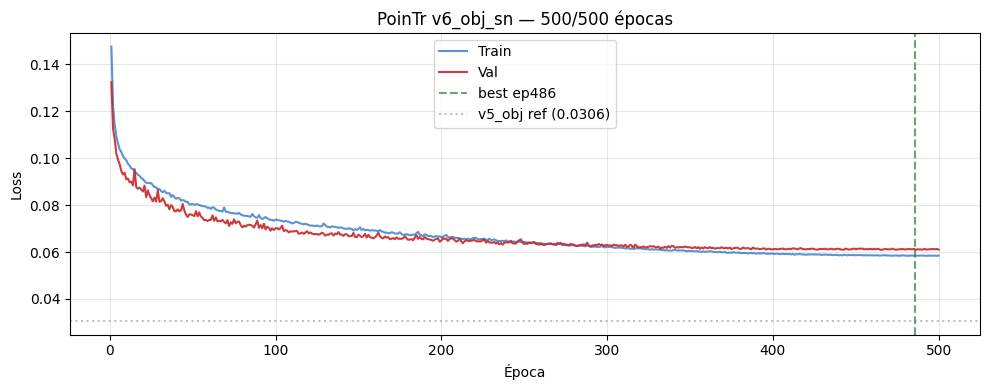

In [8]:
# ── CELDA 8 (opcional): Ver val_loss actual durante entrenamiento
# Útil para monitorizar progreso sin esperar el fin del training.
import matplotlib.pyplot as plt, torch
from pathlib import Path

DRIVE='/content/drive/MyDrive'
BASE_E3=f'{DRIVE}/Datos_E2_E3/E3/Raquel'
RUTA_SALIDA_MODELO=f'{BASE_E3}/modelos/{VERSION}'
CKPT_DIR=Path(f'E3/checkpoints_pointr_{VERSION}')

# Buscar el checkpoint más reciente
candidates = sorted(CKPT_DIR.glob('epoch_*.pt')) + \
             (sorted(Path(RUTA_SALIDA_MODELO).glob('epoch_*.pt')) if Path(RUTA_SALIDA_MODELO).exists() else [])
if not candidates:
    candidates = [CKPT_DIR/'best.pt'] if (CKPT_DIR/'best.pt').exists() else []

if not candidates:
    print('Sin checkpoints aún — ejecuta la Celda 7 primero.')
else:
    def _ep(p):
        try: return int(p.stem.split('_')[1])
        except: return 0
    latest = max(candidates, key=_ep)
    ck = torch.load(latest, map_location='cpu', weights_only=False)
    tl = ck.get('train_losses', []); vl = ck.get('val_losses', [])
    ep_actual = ck.get('epoch', len(vl))
    print(f'Checkpoint: {latest.name}  |  época {ep_actual}/{EPOCHS}')
    if vl:
        print(f'Mejor val: {min(vl):.6f}  |  Val actual (ep{ep_actual}): {vl[-1]:.6f}')
        print(f'Referencia v5_obj: 0.0306')
        fig, ax = plt.subplots(figsize=(10,4))
        eps = range(1, len(tl)+1)
        ax.plot(eps, tl, label='Train', color='#1565C0', alpha=0.7)
        ax.plot(eps, vl, label='Val',   color='#C62828', alpha=0.9)
        best_ep = vl.index(min(vl))+1
        ax.axvline(best_ep, color='#2E7D32', linestyle='--', alpha=0.7, label=f'best ep{best_ep}')
        ax.axhline(0.0306, color='gray', linestyle=':', alpha=0.5, label='v5_obj ref (0.0306)')
        ax.set_xlabel('Época'); ax.set_ylabel('Loss')
        ax.set_title(f'PoinTr {VERSION} — {ep_actual}/{EPOCHS} épocas')
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
        plt.show()
    else:
        print('Sin historial de pérdidas en el checkpoint.')

In [9]:
# ── CELDA 9: Evaluar + guardar metricas.json ───────────────────
import torch, numpy as np, random, sys, os, json, shutil
from pathlib import Path
from torch.utils.data import DataLoader
from datetime import date

sys.path.insert(0,'/content/PoinTr'); sys.path.insert(0,'/content/TFM')
os.chdir('/content/TFM')

DRIVE='/content/drive/MyDrive'
BASE_E3=f'{DRIVE}/Datos_E2_E3/E3/Raquel'
BASE_GENERAL=f'{DRIVE}/Datos_E2_E3/General'
RUTA_SALIDA_RESULTADOS=f'{BASE_E3}/resultados/{VERSION}'
RUTA_SALIDA_MODELO=f'{BASE_E3}/modelos/{VERSION}'

FUENTES_TODAS={'fb':(f'{BASE_GENERAL}/Fantastik_Break_Procesado_v2','Datos/fantastic_breaks/procesado_v2'),
               'obj':(f'{BASE_GENERAL}/roturas_Objaverse_v2','Datos/objaverse/roturas_v2'),
               'sn':(f'{BASE_GENERAL}/shapenet_roturas','Datos/shapenet/roturas')}
FUENTES_ACTIVAS={k:v for k,v in FUENTES_TODAS.items() if k in _partes}

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path=f'E3/checkpoints_pointr_{VERSION}/best.pt'
if not Path(ckpt_path).exists():
    ckpt_path=f'{RUTA_SALIDA_MODELO}/best.pt'
    print('Cargando desde Drive')
ck=torch.load(ckpt_path,map_location=device,weights_only=False)
print(f'best.pt — epoca {ck["epoch"]}')

from easydict import EasyDict
try:
    from models.build import build_model_from_cfg; model=build_model_from_cfg(EasyDict(ck['model_cfg']))
except:
    from models.PoinTr import PoinTr; model=PoinTr(EasyDict(ck['model_cfg']))
model.load_state_dict(ck['model_state_dict']); model=model.to(device); model.eval()

from E3.dataset import construir_pares, ShapeCompletionDataset
import E3.dataset as _ds; _ds.CENTRAR_EN_ROTO=False

carpetas_locales=[v[1] for v in FUENTES_ACTIVAS.values() if Path(v[1]).exists()]
_todos=construir_pares(carpetas_locales)
_rng=random.Random(42); _rng.shuffle(_todos); _n=len(_todos)
_nt=int(0.8*_n); _nv=int(0.1*_n)
_te=_todos[_nt+_nv:]
test_loader=DataLoader(ShapeCompletionDataset(_te,augmentar=False),batch_size=32,shuffle=False,pin_memory=True)
print(f'Test: {len(_te)} pares')

def chamfer_eval(p,g):
    d=torch.cdist(p,g,p=2); return ((d.min(2).values.mean()+d.min(1).values.mean())/2).item()

def fscore(p,g,th=0.01):
    dpg=torch.cdist(p,g,p=2); dgp=torch.cdist(g,p,p=2)
    pr=(dpg.min(2).values<th).float().mean(); re=(dgp.min(2).values<th).float().mean()
    if pr+re<1e-8: return 0.0
    return (2*pr*re/(pr+re)).item()

cds,fscores=[],[]
with torch.no_grad():
    for roto,completo in test_loader:
        roto,completo=roto.to(device),completo.to(device)
        out=model(roto); fine=out[-1] if isinstance(out,(list,tuple)) else out
        for i in range(len(roto)):
            p=fine[i:i+1]; g=completo[i:i+1]
            cds.append(chamfer_eval(p,g)); fscores.append(fscore(p,g))

cd_mean=np.mean(cds); fs_mean=np.mean(fscores)
print(f'\n=== {VERSION} ===')
print(f'  CD-L1   : {cd_mean:.4f}')
print(f'  F-Score : {fs_mean:.4f}')
print(f'  Muestras: {len(cds)}')
print(f'\n  Ref PoinTr v5_obj : CD=0.0306, F=0.2701 (Ob v2, 300ep)  ← referencia')
delta = cd_mean - 0.0306
print(f'  Δ vs v5_obj        : {delta:+.4f} ({"mejor" if delta<0 else "peor"})' )

metricas={
    'version': VERSION,
    'modelo': 'PoinTr',
    'fecha': str(date.today()),
    'datasets': _partes,
    'n_pares_total': _n,
    'n_test': len(cds),
    'epochs': EPOCHS,
    'best_epoch': int(ck['epoch']),
    'cd_l1': float(cd_mean),
    'f_score': float(fs_mean),
    'centrar_en_roto': False,
    'notas': ''
}

res_local=Path(f'E3/resultados_pointr_{VERSION}'); res_local.mkdir(parents=True,exist_ok=True)
with open(res_local/'metricas.json','w') as f: json.dump(metricas,f,indent=2,ensure_ascii=False)
with open(res_local/'resumen.txt','w') as f:
    f.write(f'Modelo: PoinTr {VERSION}\nDatasets: {_partes}\nEpoca best: {ck["epoch"]}\n')
    f.write(f'CD-L1: {cd_mean:.6f}\nF-Score: {fs_mean:.6f}\nMuestras test: {len(cds)}\n')
Path(RUTA_SALIDA_RESULTADOS).mkdir(parents=True,exist_ok=True)
shutil.copytree(str(res_local),RUTA_SALIDA_RESULTADOS,dirs_exist_ok=True)
print(f'\nResultados: {res_local} y Drive: {RUTA_SALIDA_RESULTADOS}')

2026-08-27 21:44:01,338 - MODEL - INFO -  Transformer with knn_layer 1


best.pt — epoca 486
Test: 251 pares

=== v6_obj_sn ===
  CD-L1   : 0.0245
  F-Score : 0.4547
  Muestras: 251

  Ref PoinTr v5_obj : CD=0.0306, F=0.2701 (Ob v2, 300ep)  ← referencia
  Δ vs v5_obj        : -0.0061 (mejor)

Resultados: E3/resultados_pointr_v6_obj_sn y Drive: /content/drive/MyDrive/Datos_E2_E3/E3/Raquel/resultados/v6_obj_sn


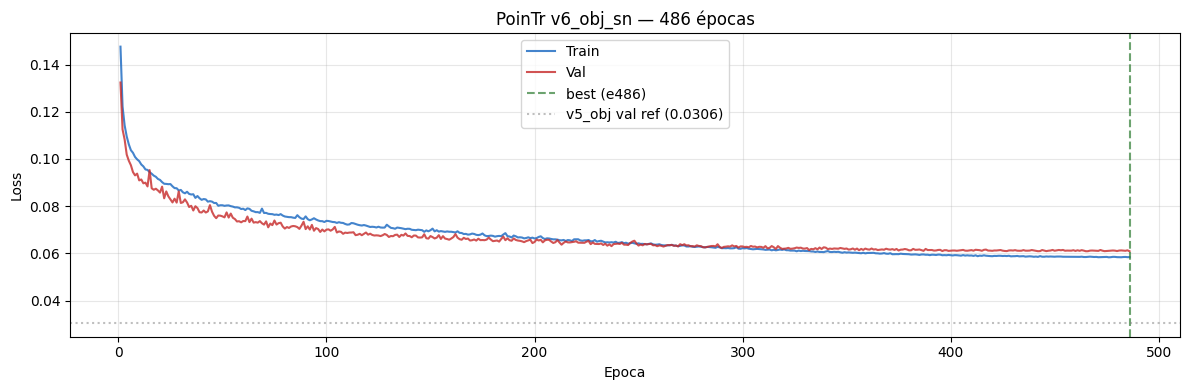

Mejor epoch: 486 | val loss: 0.060927


In [10]:
# ── CELDA 10: Curvas de aprendizaje ────────────────────────────
import matplotlib.pyplot as plt, torch
from pathlib import Path

ckpt_path=f'E3/checkpoints_pointr_{VERSION}/best.pt'
if not Path(ckpt_path).exists():
    DRIVE='/content/drive/MyDrive'
    ckpt_path=f'{DRIVE}/Datos_E2_E3/E3/Raquel/modelos/{VERSION}/best.pt'
ck=torch.load(ckpt_path,map_location='cpu',weights_only=False)

fig,ax=plt.subplots(figsize=(12,4))
eps=range(1,len(ck['train_losses'])+1)
ax.plot(eps,ck['train_losses'],label='Train',color='#1565C0',alpha=0.8)
ax.plot(eps,ck['val_losses'],  label='Val',  color='#C62828',alpha=0.8)
ax.axvline(ck['epoch'],color='#2E7D32',linestyle='--',alpha=0.7,label=f'best (e{ck["epoch"]})')
ax.axhline(0.0306, color='gray', linestyle=':', alpha=0.5, label='v5_obj val ref (0.0306)')
ax.set_xlabel('Epoca'); ax.set_ylabel('Loss'); ax.set_title(f'PoinTr {VERSION} — {len(ck["train_losses"])} épocas')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
res_local=Path(f'E3/resultados_pointr_{VERSION}'); res_local.mkdir(exist_ok=True)
plt.savefig(res_local/'curvas.png',dpi=100,bbox_inches='tight')
plt.show()
print(f'Mejor epoch: {ck["epoch"]} | val loss: {min(ck["val_losses"]):.6f}')

## Visualización 3D interactiva (Celdas 11 y 12)

Ejecutar **después de la Celda 9** (evaluar). Usan `model`, `device`, `_te`, `VERSION` dejados en memoria.

- **Celda 11 — Overlay:** roto + GT + predicción superpuestos en el mismo espacio 3D
- **Celda 12 — Error:** predicción coloreada por distancia al GT (verde=correcto, rojo=erróneo)

> En **Colab**: rota con el ratón. En **local**: aparece en blanco — ábrelo en Colab.

In [11]:
# ── CELDA 11: Overlay 3D interactivo (rota con el ratón) ───────
# ⚠️  Requiere Celda 9 ejecutada — usa: model, device, _te, VERSION
#
#   🔵 Azul transparente  = GT completo (forma de referencia)
#   🟢 Verde              = predicción PoinTr
#   🔴 Rojo               = pieza rota de entrada

import subprocess
subprocess.run(['pip','install','plotly','--quiet'], capture_output=True)

import plotly.graph_objects as go
import numpy as np, torch, random
from pathlib import Path

# ── Config ───────────────────────────────────────────────────
N_VIZ     = 6      # muestras a mostrar
ALEATORIO = True   # True = aleatorio, False = primeras N

# ── Helpers ──────────────────────────────────────────────────
def _inferir(roto_np):
    with torch.no_grad():
        inp = torch.tensor(roto_np).unsqueeze(0).to(device)
        out = model(inp)
        return (out[-1] if isinstance(out,(list,tuple)) else out).squeeze(0).cpu().numpy()

def _cd(p, g):
    pt=torch.tensor(p).unsqueeze(0); gt=torch.tensor(g).unsqueeze(0)
    d=torch.cdist(pt,gt,p=2)
    return ((d.min(2).values.mean()+d.min(1).values.mean())/2).item()

def _fs(p, g, th=0.01):
    pt=torch.tensor(p).unsqueeze(0); gt=torch.tensor(g).unsqueeze(0)
    dpg=torch.cdist(pt,gt,p=2); dgp=torch.cdist(gt,pt,p=2)
    pr=(dpg.min(2).values<th).float().mean(); re=(dgp.min(2).values<th).float().mean()
    return 0.0 if pr+re<1e-8 else (2*pr*re/(pr+re)).item()

def _nube(pts, color, name, size=2, opacity=0.7):
    return go.Scatter3d(
        x=pts[:,0], y=pts[:,1], z=pts[:,2], mode='markers', name=name,
        marker=dict(size=size, color=color, opacity=opacity))

_escena = dict(
    xaxis=dict(range=[-1.2,1.2], showticklabels=False, title='',
               backgroundcolor='#111', gridcolor='#333', zerolinecolor='#333'),
    yaxis=dict(range=[-1.2,1.2], showticklabels=False, title='',
               backgroundcolor='#111', gridcolor='#333', zerolinecolor='#333'),
    zaxis=dict(range=[-1.2,1.2], showticklabels=False, title='',
               backgroundcolor='#111', gridcolor='#333', zerolinecolor='#333'),
    bgcolor='#111', aspectmode='cube'
)

pares_viz = list(_te)
if ALEATORIO: random.shuffle(pares_viz)
pares_viz = pares_viz[:N_VIZ] if N_VIZ else pares_viz

print(f'Mostrando {len(pares_viz)} reconstrucciones — rota con el ratón:')
print('  🔵 Azul (transparente) = GT completo')
print('  🟢 Verde               = predicción PoinTr')
print('  🔴 Rojo                = pieza rota (entrada)\n')

for i, (ruta_r, ruta_c) in enumerate(pares_viz):
    roto = np.load(ruta_r).astype(np.float32)
    comp = np.load(ruta_c).astype(np.float32)
    pred = _inferir(roto)
    nombre = Path(ruta_r).stem.replace('_roto','')
    cd = _cd(pred, comp); fs = _fs(pred, comp)

    fig = go.Figure()
    fig.add_trace(_nube(comp, '#42A5F5', 'GT completo',    size=1.5, opacity=0.13))
    fig.add_trace(_nube(pred, '#66BB6A', 'Predicción',     size=2,   opacity=0.80))
    fig.add_trace(_nube(roto, '#EF5350', 'Roto (entrada)', size=3,   opacity=0.95))

    fig.update_layout(
        scene=_escena,
        title=dict(
            text=f'<b>[{i+1}/{len(pares_viz)}] {nombre}</b>'
                 f'  CD={cd:.4f}  F={fs:.4f}  | {VERSION}',
            font=dict(color='white', size=12), x=0.5),
        legend=dict(font=dict(color='white'), bgcolor='rgba(0,0,0,0.5)', x=0.01, y=0.99),
        paper_bgcolor='#111', plot_bgcolor='#111',
        height=600, width=680,
        margin=dict(l=0,r=0,t=50,b=0)
    )
    fig.show()
    print(f'  [{i+1}] {nombre[:55]:55s}  CD={cd:.4f}  F={fs:.4f}')

Mostrando 6 reconstrucciones — rota con el ratón:
  🔵 Azul (transparente) = GT completo
  🟢 Verde               = predicción PoinTr
  🔴 Rojo                = pieza rota (entrada)



  [1] shapenet_4c89f52fde77d653f4fb4dee5181bee                 CD=0.0191  F=0.4626


  [2] shapenet_2e1b664ff0cf2589577bb053711067f                 CD=0.0345  F=0.4897


  [3] objaverse_63660b72eff64e63947bd7fd84629d94_r1            CD=0.0355  F=0.0762


  [4] shapenet_117843347cde5b502b18a5129db1b7d0                CD=0.0288  F=0.2573


  [5] shapenet_9effd38015b7e5ecc34b900bb2492e                  CD=0.0139  F=0.6295


  [6] shapenet_3703ada8cc31df4337b00c4c2fbe82aa                CD=0.0231  F=0.4664


In [12]:
# ── CELDA 12: Puntos correctos vs erróneos (Plotly 3D rotable) ─
# ⚠️  Requiere Celda 9 ejecutada — usa: model, device, _te, VERSION
#
#   🟢 Verde   = correctos   (dist < UMBRAL_ERROR)
#   🔴 Rojo    = erróneos    (dist >= UMBRAL_ERROR)
#   🟠 Naranja = zonas del GT sin reconstruir
#   🔵 Azul    = GT completo (fondo transparente)

import plotly.graph_objects as go
import numpy as np, torch, random
from pathlib import Path

UMBRAL_ERROR           = 0.05
N_VIZ2                 = 6
ALEATORIO2             = True
MOSTRAR_GT_NO_CUBIERTO = True

def _inferir(roto_np):
    with torch.no_grad():
        inp = torch.tensor(roto_np).unsqueeze(0).to(device)
        out = model(inp)
        return (out[-1] if isinstance(out,(list,tuple)) else out).squeeze(0).cpu().numpy()

def _dist_min(origen, destino):
    o=torch.tensor(origen).unsqueeze(0); d_=torch.tensor(destino).unsqueeze(0)
    return torch.cdist(o,d_,p=2).min(2).values.squeeze(0).numpy()

_escena2 = dict(
    xaxis=dict(range=[-1.2,1.2], showticklabels=False, title='',
               backgroundcolor='#111', gridcolor='#333', zerolinecolor='#333'),
    yaxis=dict(range=[-1.2,1.2], showticklabels=False, title='',
               backgroundcolor='#111', gridcolor='#333', zerolinecolor='#333'),
    zaxis=dict(range=[-1.2,1.2], showticklabels=False, title='',
               backgroundcolor='#111', gridcolor='#333', zerolinecolor='#333'),
    bgcolor='#111', aspectmode='cube'
)

pares_viz2 = list(_te)
if ALEATORIO2: random.shuffle(pares_viz2)
pares_viz2 = pares_viz2[:N_VIZ2] if N_VIZ2 else pares_viz2

print(f'Umbral de error: {UMBRAL_ERROR}')
print('  🟢 Verde   = puntos correctos')
print('  🔴 Rojo    = puntos erróneos')
if MOSTRAR_GT_NO_CUBIERTO:
    print('  🟠 Naranja = zonas GT sin reconstruir')
print('  🔵 Azul    = GT completo (fondo)\n')

for i, (ruta_r, ruta_c) in enumerate(pares_viz2):
    roto = np.load(ruta_r).astype(np.float32)
    comp = np.load(ruta_c).astype(np.float32)
    pred = _inferir(roto)
    nombre = Path(ruta_r).stem.replace('_roto','')

    err_pred = _dist_min(pred, comp)
    buenos   = pred[err_pred <  UMBRAL_ERROR]
    malos    = pred[err_pred >= UMBRAL_ERROR]

    err_gt   = _dist_min(comp, pred)
    no_cub   = comp[err_gt  >= UMBRAL_ERROR]

    cd_val   = float((err_pred.mean() + err_gt.mean()) / 2)
    pct_ok   = 100 * len(buenos) / len(pred)

    fig = go.Figure()
    fig.add_trace(go.Scatter3d(
        x=comp[:,0], y=comp[:,1], z=comp[:,2], mode='markers', name='GT completo',
        marker=dict(size=1.2, color='#42A5F5', opacity=0.10)))
    if len(buenos):
        fig.add_trace(go.Scatter3d(
            x=buenos[:,0], y=buenos[:,1], z=buenos[:,2], mode='markers',
            name=f'Correctos ({len(buenos)}, {pct_ok:.0f}%)',
            marker=dict(size=2, color='#66BB6A', opacity=0.85)))
    if len(malos):
        fig.add_trace(go.Scatter3d(
            x=malos[:,0], y=malos[:,1], z=malos[:,2], mode='markers',
            name=f'Erróneos ({len(malos)}, {100-pct_ok:.0f}%)',
            marker=dict(size=2.5, color='#EF5350', opacity=0.90)))
    if MOSTRAR_GT_NO_CUBIERTO and len(no_cub):
        fig.add_trace(go.Scatter3d(
            x=no_cub[:,0], y=no_cub[:,1], z=no_cub[:,2], mode='markers',
            name=f'GT sin reconstruir ({len(no_cub)})',
            marker=dict(size=1.8, color='#FFA726', opacity=0.70)))

    fig.update_layout(
        scene=_escena2,
        title=dict(
            text=f'<b>[{i+1}/{len(pares_viz2)}] {nombre}</b>'
                 f'  CD={cd_val:.4f}  Correctos={pct_ok:.1f}%  Umbral={UMBRAL_ERROR}',
            font=dict(color='white', size=11), x=0.5),
        legend=dict(font=dict(color='white'), bgcolor='rgba(0,0,0,0.6)', x=0.01, y=0.99),
        paper_bgcolor='#111', plot_bgcolor='#111',
        height=620, width=700,
        margin=dict(l=0,r=0,t=50,b=0)
    )
    fig.show()
    print(f'  [{i+1}] {nombre[:45]:45s}  '
          f'CD={cd_val:.4f}  ok={pct_ok:.0f}%  '
          f'erróneos={len(malos)}  GT_sin_cubrir={len(no_cub)}')

Umbral de error: 0.05
  🟢 Verde   = puntos correctos
  🔴 Rojo    = puntos erróneos
  🟠 Naranja = zonas GT sin reconstruir
  🔵 Azul    = GT completo (fondo)



  [1] shapenet_14588e373cdb9143ca972ee98a070b3d      CD=0.0177  ok=92%  erróneos=311  GT_sin_cubrir=344


  [2] shapenet_62d897a92c86cb392ab20b9ffcec9f65      CD=0.0302  ok=86%  erróneos=588  GT_sin_cubrir=583


  [3] shapenet_f1e439307b834015770a0ff1161fa15a      CD=0.0252  ok=86%  erróneos=554  GT_sin_cubrir=373


  [4] objaverse_1095a05d184b428199b791deea8b9724_r0  CD=0.0306  ok=83%  erróneos=700  GT_sin_cubrir=316


  [5] shapenet_fa23aa60ec51c8e4c40fe5637f0a27e1      CD=0.0233  ok=90%  erróneos=404  GT_sin_cubrir=202


  [6] shapenet_93c837235aa98a7ee685b534d1dbc410      CD=0.0297  ok=78%  erróneos=896  GT_sin_cubrir=375
